## Deep Bidirectional LSTM Model 

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import time
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

2025-02-16 22:24:02.856901: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-16 22:24:03.053072: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739762643.147051   15475 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739762643.175367   15475 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-16 22:24:03.411387: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
data = {
    "Category": [
        "Model Configuration", "Smoothing Used", "Training Data Check", "Testing Data Check", 
        "Confusion Matrix", "F1 Score (Positive)", "F1 Score (Negative)", "AUC", "Accuracy", 
        "Feature Engineering", "Feature Weightages Added", "2 Features with Highest Weights", 
        "Cross Validation", "Data Preprocessing", "Emoji Handling", "Slang Handling", 
        "Abbreviation Handling", "Next Steps"
    ],
    "Details": [
        "2 BiLSTM layers (64, 32), Dropout (0.5), Dense (64, ReLU), Softmax (5 classes)", "None", "Done", "Done",
        "Yes", "0.85", "0.62", "Yes, AUC = 0.70", 
        "Yes, Accuracy = 0.693", "Done", "No", "Not applicable (Feature-based models like Naive Bayes)",
        "Not performed explicitly", "Text cleaning, tokenization, padding, label encoding", "Yes (converted to text tokens)",
        "Yes (via text preprocessing)", "Not explicitly handled", 
        "Tune hyperparameters (batch size, learning rate), try different architectures (GRU, Transformer), explore pre-trained embeddings (GloVe, FastText)"
    ]
}

# Create a pandas DataFrame
model_config_df = pd.DataFrame(data)
pd.set_option('display.max_colwidth', None)


model_config_df

,Category,Details
0,Model Configuration,"2 BiLSTM layers (64, 32), Dropout (0.5), Dense (64, ReLU), Softmax (5 classes)"
1,Smoothing Used,None
2,Training Data Check,Done
3,Testing Data Check,Done
4,Confusion Matrix,Yes
5,F1 Score (Positive),0.85
6,F1 Score (Negative),0.62
7,AUC,"Yes, AUC = 0.70"
8,Accuracy,"Yes, Accuracy = 0.693"
9,Feature Engineering,Done


In [77]:
data = pd.read_csv("Sentiment_Data.csv", encoding="ISO-8859-1").sample(n=25000, random_state=10)


In [78]:
import re

def preprocess_text(text):
    if isinstance(text, str):  # Ensure text is a string
        text = text.lower()
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # Remove URLs
        text = re.sub(r"@\w+", "", text)  # Remove mentions
        text = re.sub(r"#\w+", "", text)  # Remove hashtags
        text = re.sub(r"[^\w\s]", "", text)  # Remove special characters
        text = tf.keras.preprocessing.text.text_to_word_sequence(text)
        return " ".join(text)
    return ""

data["Processed_Tweet"] = data["Tweet"].apply(preprocess_text)


In [79]:
import emoji

def convert_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))  # Convert emojis to text

data["Processed_Tweet"] = data["Processed_Tweet"].apply(convert_emojis)


In [80]:
slang_dict = {
    "brb": "be right back",
    "lol": "laughing out loud",
    "idk": "i don’t know",
    "btw": "by the way",
    "imo": "in my opinion"
}

def replace_slang(text):
    words = text.split()
    return " ".join([slang_dict[word] if word in slang_dict else word for word in words])

data["Processed_Tweet"] = data["Processed_Tweet"].apply(replace_slang)


In [81]:
max_vocab = 20000
max_length = 50
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(data["Processed_Tweet"])
sequences = tokenizer.texts_to_sequences(data["Processed_Tweet"])
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post")


In [82]:
data["Sentiment"].value_counts()

Sentiment
Strong_Pos    12901
Neutral        4176
Mild_Pos       3606
Strong_Neg     2363
Mild_Neg       1954
Name: count, dtype: int64

In [83]:
# Convert Sentiments to Numeric Labels
sentiment_mapping = {"Strong_Pos": 4, "Mild_Pos": 3, "Neutral": 2, "Mild_Neg": 1, "Strong_Neg": 0}
data["Sentiment_Label"] = data["Sentiment"].map(sentiment_mapping)


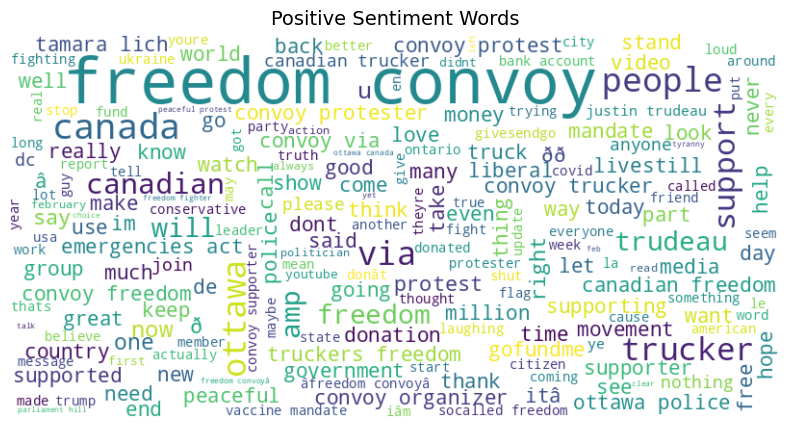

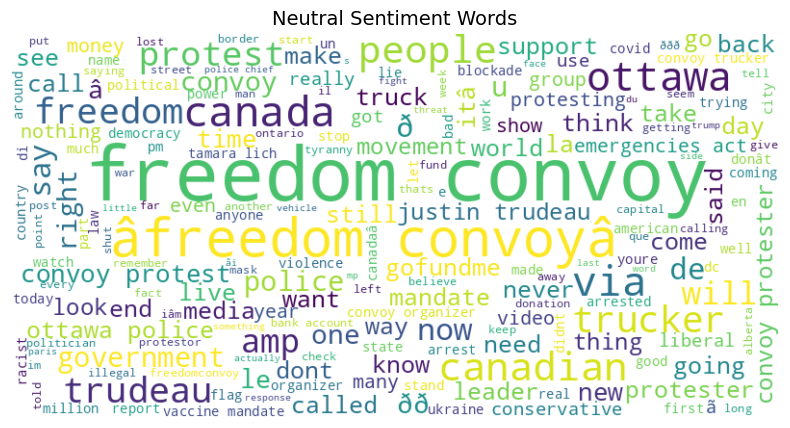

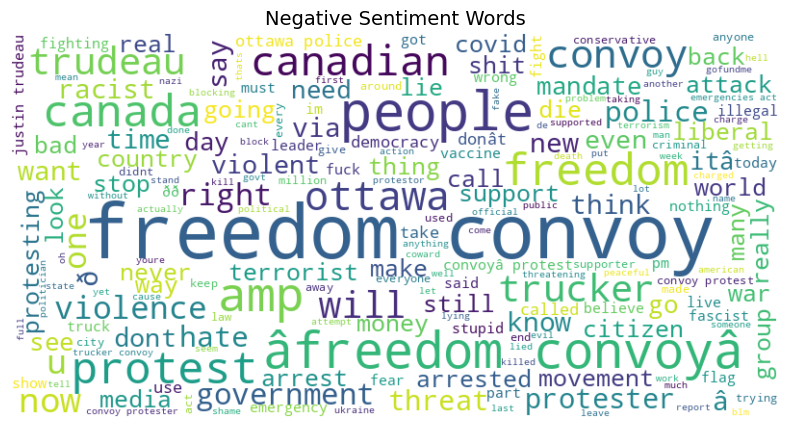

In [84]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate a word cloud
def plot_wordcloud(sentiment_label, title):
    text = " ".join(data[data["Sentiment_Label"] == sentiment_label]["Processed_Tweet"])
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()

# Generate word clouds for different sentiment categories
plot_wordcloud(4, "Positive Sentiment Words")
plot_wordcloud(2, "Neutral Sentiment Words")
plot_wordcloud(0, "Negative Sentiment Words")


In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, data["Sentiment_Label"], test_size=0.18, random_state=42
)

In [86]:
def build_model():
    model = Sequential([
        Embedding(input_dim=max_vocab, output_dim=100, input_length=max_length),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(5, activation="softmax")  # Adjusted for five sentiment classes
    ])
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

In [87]:
basic_model = build_model()
start_time = time.time()
basic_history = basic_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))
basic_train_time = time.time() - start_time

/home/saraka/tf/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.5498 - loss: 1.2677 - val_accuracy: 0.6573 - val_loss: 0.9054
Epoch 2/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7078 - loss: 0.7883 - val_accuracy: 0.6956 - val_loss: 0.8188
Epoch 3/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7810 - loss: 0.5947 - val_accuracy: 0.6944 - val_loss: 0.8368
Epoch 4/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.8359 - loss: 0.4581 - val_accuracy: 0.6976 - val_loss: 0.8707
Epoch 5/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.8696 - loss: 0.3678 - val_accuracy: 0.7024 - val_loss: 0.9445
Epoch 6/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9000 - loss: 0.2935 - val_accuracy: 0.6949 - val_loss: 1.1360
Epoch 7/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.9142 - loss: 0.2559 - val_accuracy: 0.6811 - val_loss: 1.1568
Epoch 8/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.9297 - loss: 0.2106 - 

In [88]:
# Compute Class Weights
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights[i] for i in range(len(class_weights))}
print(class_weights)

weighted_model = build_model()
start_time = time.time()
weighted_history = weighted_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), class_weight=class_weights)
weighted_train_time = time.time() - start_time

{0: np.float64(2.11231324059763), 1: np.float64(2.5593008739076155), 2: np.float64(1.197080291970803), 3: np.float64(1.3823331085637223), 4: np.float64(0.3880371001325005)}
Epoch 1/10


/home/saraka/tf/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


321/321 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.3383 - loss: 1.5028 - val_accuracy: 0.6504 - val_loss: 0.9627
Epoch 2/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.6563 - loss: 1.0452 - val_accuracy: 0.6680 - val_loss: 0.8899
Epoch 3/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7385 - loss: 0.7869 - val_accuracy: 0.6278 - val_loss: 0.9693
Epoch 4/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.7958 - loss: 0.6186 - val_accuracy: 0.6649 - val_loss: 0.9574
Epoch 5/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.8433 - loss: 0.4718 - val_accuracy: 0.6640 - val_loss: 1.0234
Epoch 6/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8793 - loss: 0.3788 - val_accuracy: 0.6716 - val_loss: 1.0929
Epoch 7/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - accuracy: 0.9005 - loss: 0.2973 - val_accuracy: 0.6791 - val_loss: 1.2308
Epoch 8/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9208 - loss: 0.2456 - val_accurac

In [91]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def evaluate_model(model, X_test, y_test, model_name, train_time):
    # Predict the class labels
    y_pred = np.argmax(model.predict(X_test), axis=1)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Generate classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Compute AUC (for multi-class)
    auc = roc_auc_score(pd.get_dummies(y_test), pd.get_dummies(y_pred), multi_class="ovr")
    
    # Print evaluation results
    print(f"\nModel: {model_name}")
    print(f"Training Time: {train_time:.2f} seconds")
    print(f"Accuracy: {acc}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    print("Confusion Matrix:")
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()
    
    # Plot AUC for all classes and print individual AUC values
    plt.figure(figsize=(8,6))
    auc_values = {}
    for i in range(5):
        fpr, tpr, _ = roc_curve(pd.get_dummies(y_test).iloc[:, i], pd.get_dummies(y_pred).iloc[:, i])
        plt.plot(fpr, tpr, label=f'Class {i}')
        
        # Calculate and print AUC for each class
        class_auc = roc_auc_score(pd.get_dummies(y_test).iloc[:, i], pd.get_dummies(y_pred).iloc[:, i])
        auc_values[f'Class {i}'] = class_auc
        print(f"AUC for Class {i}: {class_auc:.4f}")
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"{model_name} ROC Curve")
    plt.legend()
    plt.show()
    
    return acc, report, auc


141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

Model: Basic Model
Training Time: 205.44 seconds
Accuracy: 0.6937777777777778
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.56      0.62       422
           1       0.38      0.44      0.41       352
           2       0.60      0.62      0.61       751
           3       0.43      0.49      0.46       640
           4       0.87      0.84      0.85      2335

    accuracy                           0.69      4500
   macro avg       0.59      0.59      0.59      4500
weighted avg       0.71      0.69      0.70      4500

Confusion Matrix:


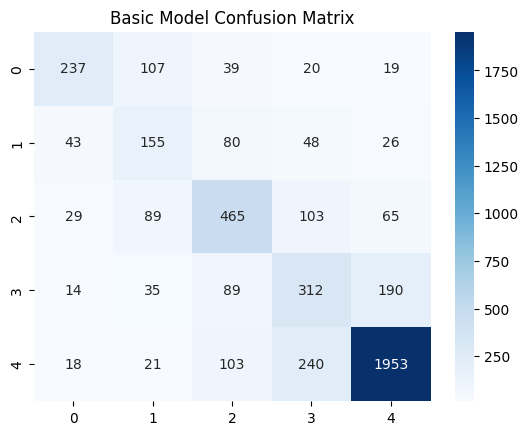

AUC for Class 0: 0.7681
AUC for Class 1: 0.6898
AUC for Class 2: 0.7681
AUC for Class 3: 0.6905
AUC for Class 4: 0.8489


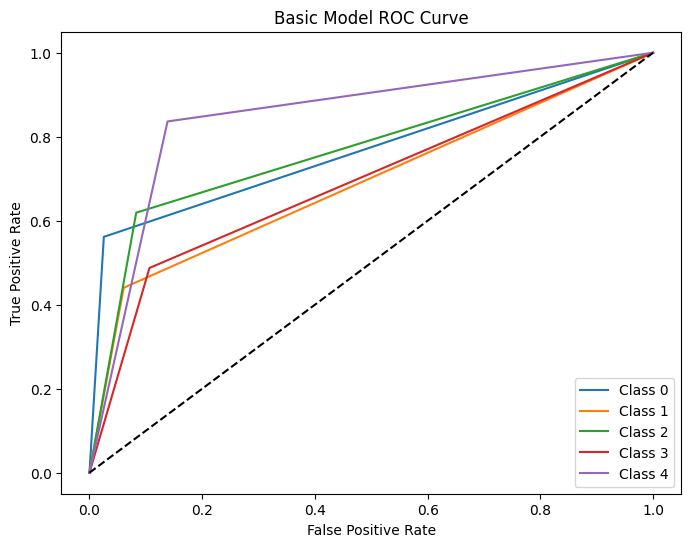

In [92]:
basic_acc, basic_report, basic_auc = evaluate_model(basic_model, X_test, y_test, "Basic Model", basic_train_time)

141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step

Model: Weighted Model
Training Time: 212.24 seconds
Accuracy: 0.6542222222222223
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57       422
           1       0.39      0.44      0.41       352
           2       0.62      0.60      0.61       751
           3       0.36      0.66      0.47       640
           4       0.91      0.73      0.81      2335

    accuracy                           0.65      4500
   macro avg       0.58      0.59      0.57      4500
weighted avg       0.72      0.65      0.67      4500

Confusion Matrix:


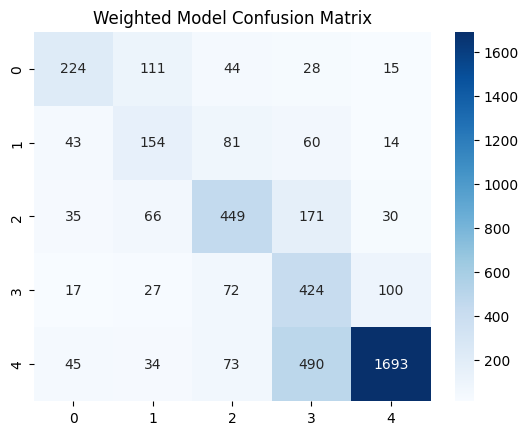

AUC for Class 0: 0.7482
AUC for Class 1: 0.6901
AUC for Class 2: 0.7629
AUC for Class 3: 0.7342
AUC for Class 4: 0.8258


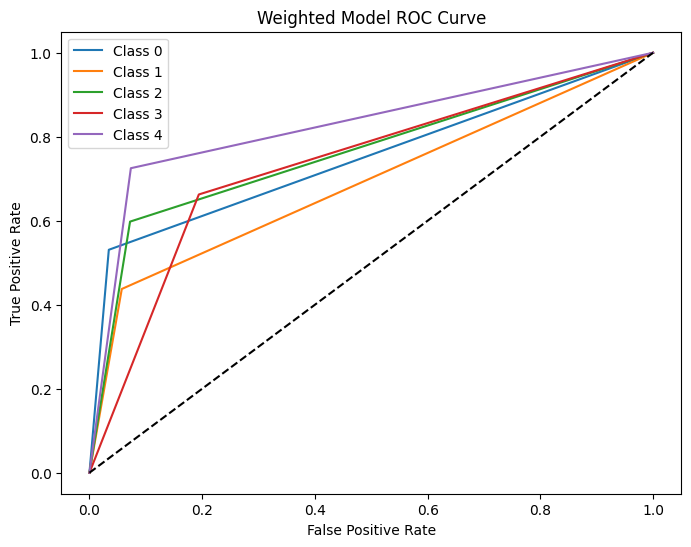

In [93]:
weighted_acc, weighted_report, weighted_auc = evaluate_model(weighted_model, X_test, y_test, "Weighted Model", weighted_train_time)